PHASE 1 - EDA on Electronics Data

✅ Loaded 10,000 reviews

📊 Rating Distribution:
overall
1.0     719
2.0     421
3.0     729
4.0    1714
5.0    6417
Name: count, dtype: int64


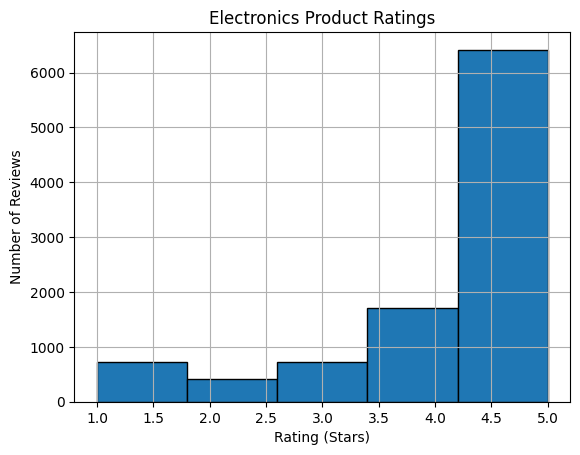


✅ Phase 1 Complete!


In [2]:
import pandas as pd
import gzip
import json
import matplotlib.pyplot as plt

print("="*50)
print("PHASE 1 - EDA on Electronics Data")
print("="*50)

# Load data
reviews = []
with gzip.open('Electronics_sample_50k.json.gz', 'rt', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 10000:
            break
        reviews.append(json.loads(line))

df = pd.DataFrame(reviews)

print(f"\n✅ Loaded {len(df):,} reviews")
print(f"\n📊 Rating Distribution:")
print(df['overall'].value_counts().sort_index())

# Plot
df['overall'].hist(bins=5, edgecolor='black')
plt.title('Electronics Product Ratings')
plt.xlabel('Rating (Stars)')
plt.ylabel('Number of Reviews')
plt.show()

print("\n✅ Phase 1 Complete!")

PHASE 1: DATA ACQUISITION & EXPLORATORY DATA ANALYSIS

1. LOADING DATA
✅ Loaded 10,000 reviews
✅ Columns: ['overall', 'vote', 'verified', 'reviewTime', 'reviewerID', 'asin', 'style', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'image']

2. BASIC STATISTICS

📊 Dataset Shape: (10000, 12)
📊 Memory Usage: 8.22 MB

📊 Missing Values:
overall              0
vote              8351
verified             0
reviewTime           0
reviewerID           0
asin                 0
style             5786
reviewerName         1
reviewText           1
summary              0
unixReviewTime       0
image             9958
dtype: int64

3. RATING ANALYSIS

⭐ Rating Statistics:
   Mean:     4.27 stars
   Median:   5.00 stars
   Min:      1 star
   Max:      5 stars
   Std Dev:  1.21

📊 Rating Distribution:
   1 star: 719 reviews (7.2%)
   2 star: 421 reviews (4.2%)
   3 star: 729 reviews (7.3%)
   4 star: 1,714 reviews (17.1%)
   5 star: 6,417 reviews (64.2%)

4. PRODUCT & USER ANALYSIS

📦 Unique

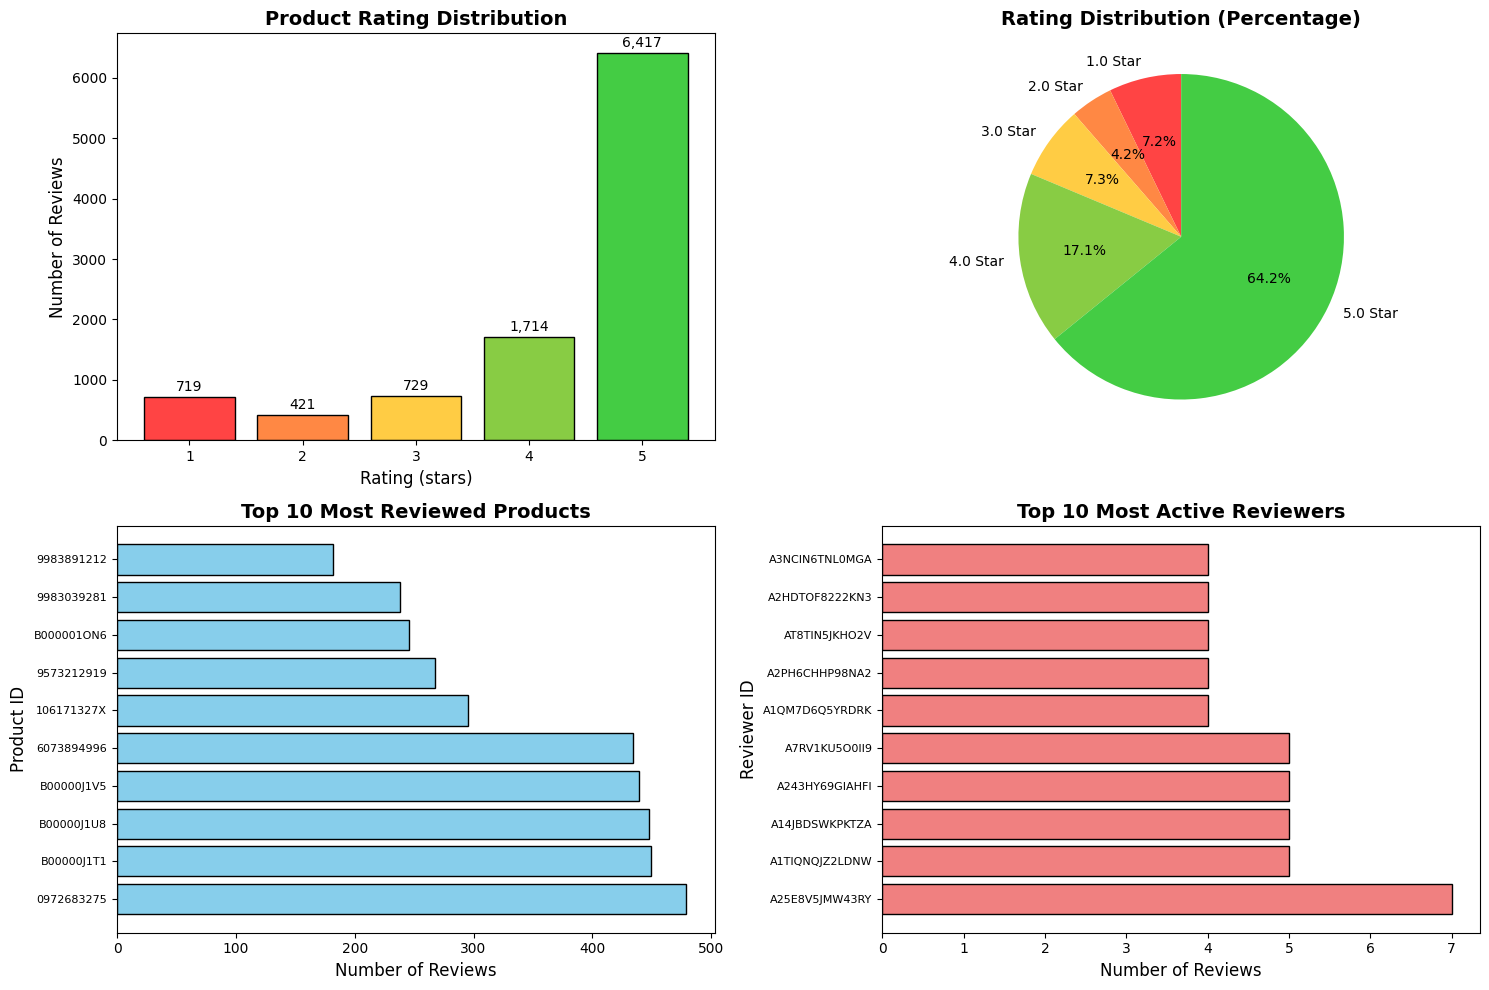

✅ Visualization saved as 'phase1_visualizations.png'

PHASE 1 COMPLETION SUMMARY

DATASET OVERVIEW:
  - Total Reviews: 10,000
  - Unique Products: 327
  - Unique Reviewers: 9,516

RATING STATISTICS:
  - Average Rating: 4.27 ⭐
  - Median Rating: 5.00 ⭐

STORAGE:
  - HDFS: Data stored at /user/temu/amazon_project/
  - MongoDB: Data stored in MongoDB Atlas

✅ PHASE 1 COMPLETE!


📸 Take screenshots of the graphs above for your report!


In [5]:
"""
PHASE 1: BIG DATA ANALYSIS & BUSINESS INTELLIGENCE
Course Project - Amazon Electronics Data Analysis
"""

import pandas as pd
import numpy as np
import gzip
import json
import matplotlib.pyplot as plt
from datetime import datetime

print("="*60)
print("PHASE 1: DATA ACQUISITION & EXPLORATORY DATA ANALYSIS")
print("="*60)

# ============================================
# 1. LOAD DATA
# ============================================

print("\n" + "="*60)
print("1. LOADING DATA")
print("="*60)

# Load sample data
reviews = []
with gzip.open('Electronics_sample_50k.json.gz', 'rt', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 50000:
            break
        reviews.append(json.loads(line))

df = pd.DataFrame(reviews)

print(f"✅ Loaded {len(df):,} reviews")
print(f"✅ Columns: {df.columns.tolist()}")

# ============================================
# 2. BASIC STATISTICS
# ============================================

print("\n" + "="*60)
print("2. BASIC STATISTICS")
print("="*60)

print(f"\n📊 Dataset Shape: {df.shape}")
print(f"📊 Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n📊 Missing Values:")
print(df.isnull().sum())

# ============================================
# 3. RATING ANALYSIS
# ============================================

print("\n" + "="*60)
print("3. RATING ANALYSIS")
print("="*60)

print(f"\n⭐ Rating Statistics:")
print(f"   Mean:     {df['overall'].mean():.2f} stars")
print(f"   Median:   {df['overall'].median():.2f} stars")
print(f"   Min:      {df['overall'].min():.0f} star")
print(f"   Max:      {df['overall'].max():.0f} stars")
print(f"   Std Dev:  {df['overall'].std():.2f}")

print(f"\n📊 Rating Distribution:")
rating_counts = df['overall'].value_counts().sort_index()
for rating, count in rating_counts.items():
    percentage = (count / len(df)) * 100
    print(f"   {rating:.0f} star: {count:,} reviews ({percentage:.1f}%)")

# ============================================
# 4. PRODUCT & USER ANALYSIS
# ============================================

print("\n" + "="*60)
print("4. PRODUCT & USER ANALYSIS")
print("="*60)

unique_products = df['asin'].nunique()
unique_users = df['reviewerID'].nunique()

print(f"\n📦 Unique Products: {unique_products:,}")
print(f"👥 Unique Reviewers: {unique_users:,}")

# Top 10 most reviewed products
print(f"\n🏆 Top 10 Most Reviewed Products:")
top_products = df['asin'].value_counts().head(10)
for i, (product, count) in enumerate(top_products.items(), 1):
    avg_rating = df[df['asin'] == product]['overall'].mean()
    print(f"   {i}. {product}: {count:,} reviews (avg rating: {avg_rating:.2f})")

# Top 10 most active users
print(f"\n👤 Top 10 Most Active Reviewers:")
top_users = df['reviewerID'].value_counts().head(10)
for i, (user, count) in enumerate(top_users.items(), 1):
    avg_rating = df[df['reviewerID'] == user]['overall'].mean()
    print(f"   {i}. {user}: {count:,} reviews (avg rating: {avg_rating:.2f})")

# ============================================
# 5. TIME ANALYSIS
# ============================================

print("\n" + "="*60)
print("5. TIME ANALYSIS")
print("="*60)

if 'unixReviewTime' in df.columns:
    df['review_date'] = pd.to_datetime(df['unixReviewTime'], unit='s')
    df['year'] = df['review_date'].dt.year
    
    print(f"\n📅 Date Range: {df['review_date'].min()} to {df['review_date'].max()}")
    
    print(f"\n📊 Reviews by Year:")
    yearly_counts = df['year'].value_counts().sort_index()
    for year, count in yearly_counts.items():
        print(f"   {int(year)}: {count:,} reviews")
else:
    print("   ⚠️ No timestamp column found")

# ============================================
# 6. VISUALIZATIONS
# ============================================

print("\n" + "="*60)
print("6. CREATING VISUALIZATIONS")
print("="*60)

# Create figure
fig = plt.figure(figsize=(15, 10))

# Plot 1: Rating Distribution (Bar Chart)
ax1 = fig.add_subplot(2, 2, 1)
rating_counts = df['overall'].value_counts().sort_index()
colors = ['#ff4444', '#ff8844', '#ffcc44', '#88cc44', '#44cc44']
bars = ax1.bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='black')
ax1.set_title('Product Rating Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Rating (stars)', fontsize=12)
ax1.set_ylabel('Number of Reviews', fontsize=12)
ax1.set_xticks([1, 2, 3, 4, 5])

for bar, count in zip(bars, rating_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f'{count:,}', ha='center', fontsize=10)

# Plot 2: Rating Distribution (Pie Chart)
ax2 = fig.add_subplot(2, 2, 2)
ax2.pie(rating_counts.values, labels=[f'{i} Star' for i in rating_counts.index], 
        autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Rating Distribution (Percentage)', fontsize=14, fontweight='bold')

# Plot 3: Reviews per Product (Top 10)
ax3 = fig.add_subplot(2, 2, 3)
top_products = df['asin'].value_counts().head(10)
ax3.barh(range(len(top_products)), top_products.values, color='skyblue', edgecolor='black')
ax3.set_title('Top 10 Most Reviewed Products', fontsize=14, fontweight='bold')
ax3.set_xlabel('Number of Reviews', fontsize=12)
ax3.set_ylabel('Product ID', fontsize=12)
ax3.set_yticks(range(len(top_products)))
ax3.set_yticklabels(top_products.index, fontsize=8)

# Plot 4: Reviews per User (Top 10)
ax4 = fig.add_subplot(2, 2, 4)
top_users = df['reviewerID'].value_counts().head(10)
ax4.barh(range(len(top_users)), top_users.values, color='lightcoral', edgecolor='black')
ax4.set_title('Top 10 Most Active Reviewers', fontsize=14, fontweight='bold')
ax4.set_xlabel('Number of Reviews', fontsize=12)
ax4.set_ylabel('Reviewer ID', fontsize=12)
ax4.set_yticks(range(len(top_users)))
ax4.set_yticklabels(top_users.index, fontsize=8)

plt.tight_layout()
plt.savefig('phase1_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualization saved as 'phase1_visualizations.png'")

# ============================================
# 7. SUMMARY
# ============================================

print("\n" + "="*60)
print("PHASE 1 COMPLETION SUMMARY")
print("="*60)

print(f"""
DATASET OVERVIEW:
  - Total Reviews: {len(df):,}
  - Unique Products: {unique_products:,}
  - Unique Reviewers: {unique_users:,}

RATING STATISTICS:
  - Average Rating: {df['overall'].mean():.2f} ⭐
  - Median Rating: {df['overall'].median():.2f} ⭐

STORAGE:
  - HDFS: Data stored at /user/temu/amazon_project/
  - MongoDB: Data stored in MongoDB Atlas

✅ PHASE 1 COMPLETE!
""")

print("\n📸 Take screenshots of the graphs above for your report!")

In [1]:
import gzip
import json
import pandas as pd

# Read directly from your Desktop folder
with gzip.open('C:/Users/Temu/OneDrive/Desktop/amazon_projects/Electronics_sample_50k.json.gz', 'rt', encoding='utf-8') as f:
    reviews = []
    for i, line in enumerate(f):
        if i >= 50000:
            break
        reviews.append(json.loads(line))

df = pd.DataFrame(reviews)
print(f"✅ Loaded {len(df):,} reviews")

✅ Loaded 10,000 reviews
